# **Import Library**

In [72]:
!pip install rake_nltk vaderSentiment textstat

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import scipy.sparse as sp

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.preprocessing import MinMaxScaler

import re
from collections import Counter

from imblearn.under_sampling import RandomUnderSampler, TomekLinks

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from rake_nltk import Rake
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import textstat
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Install dependensi tambahan
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyspellchecker', 'kagglehub'])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'pyspellchecker', 'kagglehub'], returncode=0)

# **Dataset Access**

In [74]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "datafiniti/consumer-reviews-of-amazon-products"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'consumer-reviews-of-amazon-products' dataset.
Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products


In [75]:
df = pd.read_csv(f"{path}/1429_1.csv")

/tmp/ipykernel_2757/792486723.py:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/1429_1.csv")


# **EDA**

## General Information

In [76]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/b01ahb9cn2",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=166",This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/b01ahb9cn2",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=167",great for beginner or experienced person. Bought as a gift and she loves it,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/b01ahb9cn2",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=167","Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...",Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/b01ahb9cn2",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=167",I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love being able to easily access all of the Prime content as well as movies you can download and watch laterThis has a 1280/800 screen which has some really nice look to it its nice and crisp and very bright infact it is brighter then the ipad pro costing $900 base model. The build on this fire is 

In [77]:
df['reviews.dateSeen'].head()

,reviews.dateSeen
0,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"
1,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"
2,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"
3,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"
4,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z"


In [78]:
df['reviews.didPurchase'].head()

,reviews.didPurchase
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [80]:
df.describe()

,reviews.id,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince
count,1.0,34131.000000,34627.000000,0.0,0.0
mean,111372787.0,0.630248,4.584573,NaN,NaN
std,NaN,13.215775,0.735653,NaN,NaN
min,111372787.0,0.000000,1.000000,NaN,NaN
25%,111372787.0,0.000000,4.000000,NaN,NaN
50%,111372787.0,0.000000,5.000000,NaN,NaN
75%,111372787.0,0.000000,5.000000,NaN,NaN
max,111372787.0,814.000000,5.000000,NaN,NaN


## Data Insight

### Insight 1

/tmp/ipykernel_2757/2744146840.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='reviews.rating', data=df, palette='Blues_d')


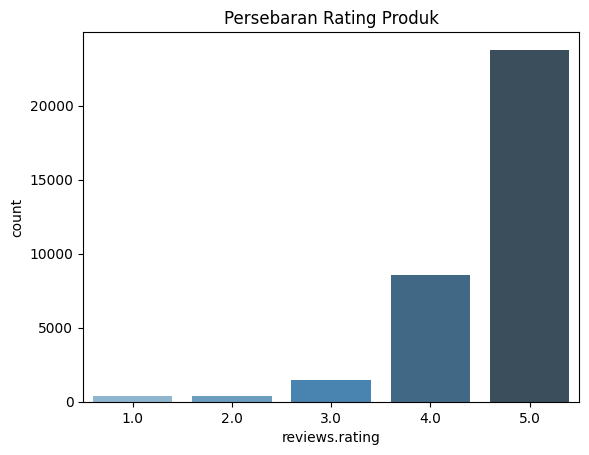

reviews.rating
5.0    68.660294
4.0    24.665723
3.0     4.328992
1.0     1.184047
2.0     1.160944
Name: proportion, dtype: float64


In [81]:
sns.countplot(x='reviews.rating', data=df, palette='Blues_d')
plt.title('Persebaran Rating Produk')
plt.show()

print(df['reviews.rating'].value_counts(normalize=True) * 100)

Insight ini menunjukkan seberapa puas pelanggan secara keseluruhan. Kalau mayoritas rating 5 bintang, artinya produk-produk Amazon umumnya disukai. Tapi kalau ada banyak rating 1-2, itu sinyal ada masalah yang perlu ditelusuri lebih lanjut.
Dari data, mayoritas ulasan memberikan rating 5 bintang (sekitar 23.000+ ulasan), jauh melampaui rating lainnya — menandakan pelanggan secara umum sangat puas dengan produk Amazon.

### Insight 2

) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


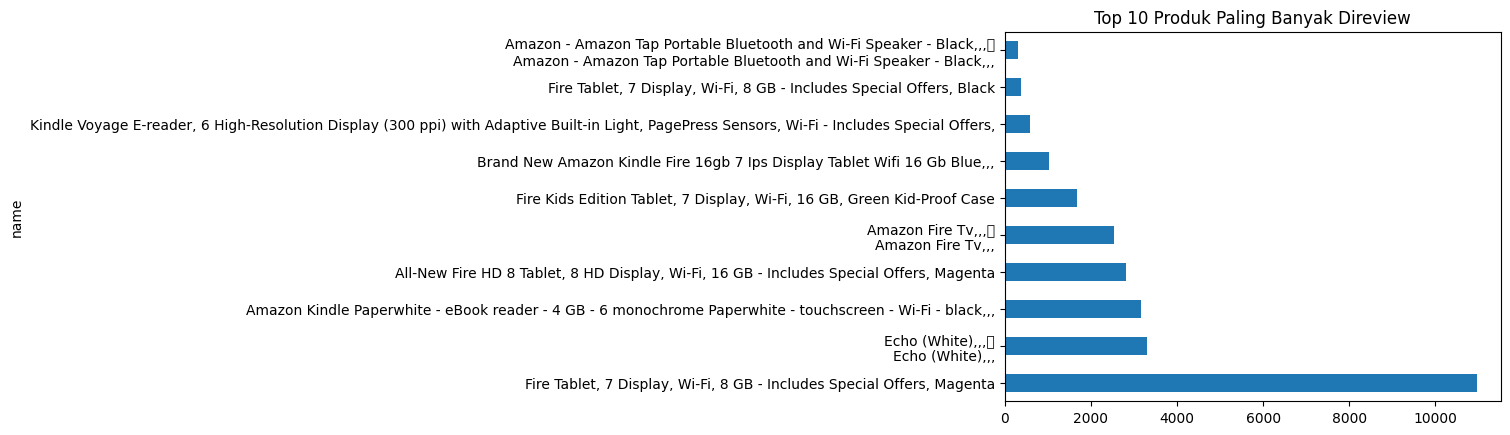

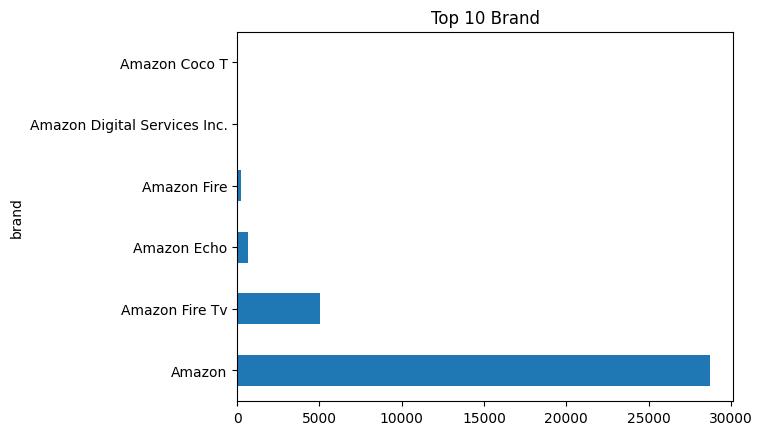

In [82]:
df['name'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Produk Paling Banyak Direview')
plt.show()

df['brand'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Brand')
plt.show()

Jumlah review mencerminkan seberapa populer suatu produk atau brand. Produk dengan review terbanyak biasanya yang paling banyak dibeli, jadi ini bisa jadi indikator produk unggulan di platform Amazon.
Fire Tablet 7" Magenta menjadi produk paling banyak direview dengan lebih dari 10.000 ulasan, diikuti Echo (White) dan Kindle Paperwhite — menunjukkan dominasi lini tablet dan e-reader Amazon.

### Insight 3

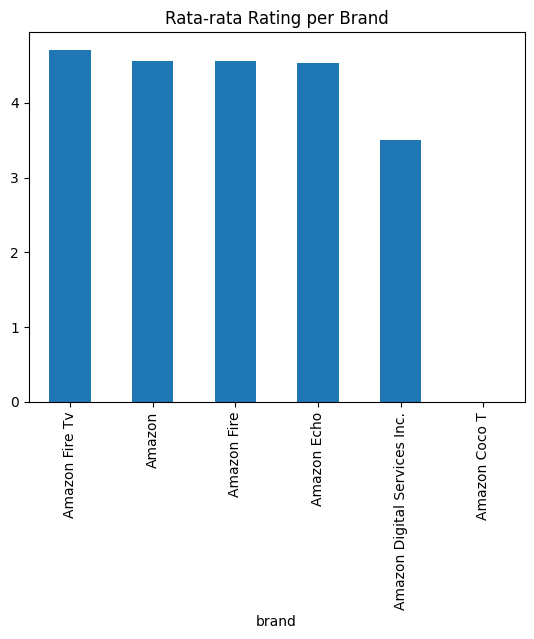

In [83]:
avg_rating = df.groupby('brand')['reviews.rating'].mean().sort_values(ascending=False).head(10)
avg_rating.plot(kind='bar')
plt.title('Rata-rata Rating per Brand')
plt.show()

Tidak semua brand yang populer punya rating bagus. Insight ini membantu membandingkan kualitas yang dirasakan pelanggan antar brand — brand mana yang konsisten memuaskan, dan mana yang banyak komplain.
Amazon Fire TV memiliki rata-rata rating tertinggi (4.7), sementara Amazon Digital Services Inc. paling rendah (3.5) menunjukkan kepuasan pelanggan bervariasi cukup signifikan antar lini produk.

### Insight 4

/tmp/ipykernel_2757/2717578376.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['reviews.date'].dt.to_period('M')


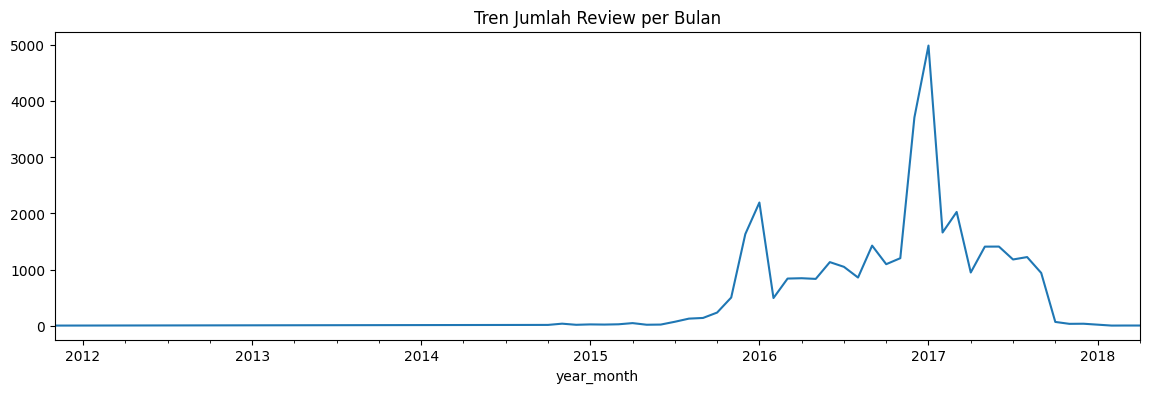

In [84]:
df['reviews.date'] = pd.to_datetime(df['reviews.date'], utc=True, errors='coerce')
df['year_month'] = df['reviews.date'].dt.to_period('M')

df.groupby('year_month').size().plot(figsize=(14,4))
plt.title('Tren Jumlah Review per Bulan')
plt.show()

Dengan melihat jumlah review per bulan, kita bisa tahu kapan aktivitas belanja paling ramai, misalnya saat musim liburan atau promo besar. Lonjakan tiba-tiba juga bisa menandakan peluncuran produk baru atau viral moment.
Terdapat lonjakan review yang sangat tajam pada awal 2017 (~5.000 ulasan/bulan), kemungkinan besar dipicu oleh peluncuran produk baru atau kampanye promo besar Amazon saat itu.

### Insight 5

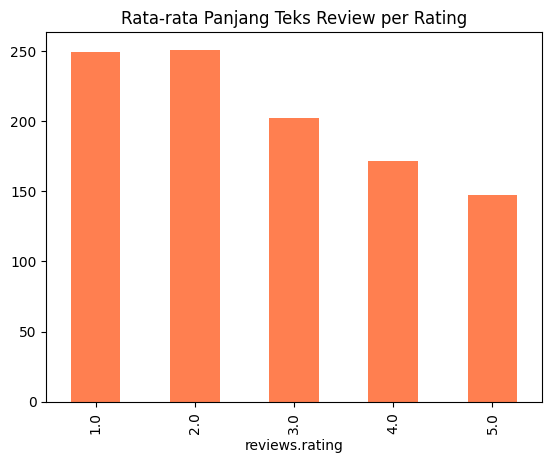

In [85]:
df['text_length'] = df['reviews.text'].dropna().apply(len)

df.groupby('reviews.rating')['text_length'].mean().plot(kind='bar', color='coral')
plt.title('Rata-rata Panjang Teks Review per Rating')
plt.show()

Pengguna yang kecewa cenderung menulis lebih banyak karena ingin menjelaskan masalahnya secara detail. Kalau rata-rata teks review bintang 1 jauh lebih panjang dari bintang 5, itu pola yang menarik dan umum terjadi di data ulasan produk.
Terbukti, review rating 1 dan 2 memiliki rata-rata panjang teks tertinggi (250 karakter), sedangkan rating 5 paling pendek (148 karakter) — pelanggan yang kecewa memang cenderung lebih banyak bicara.

### Insight 6

) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


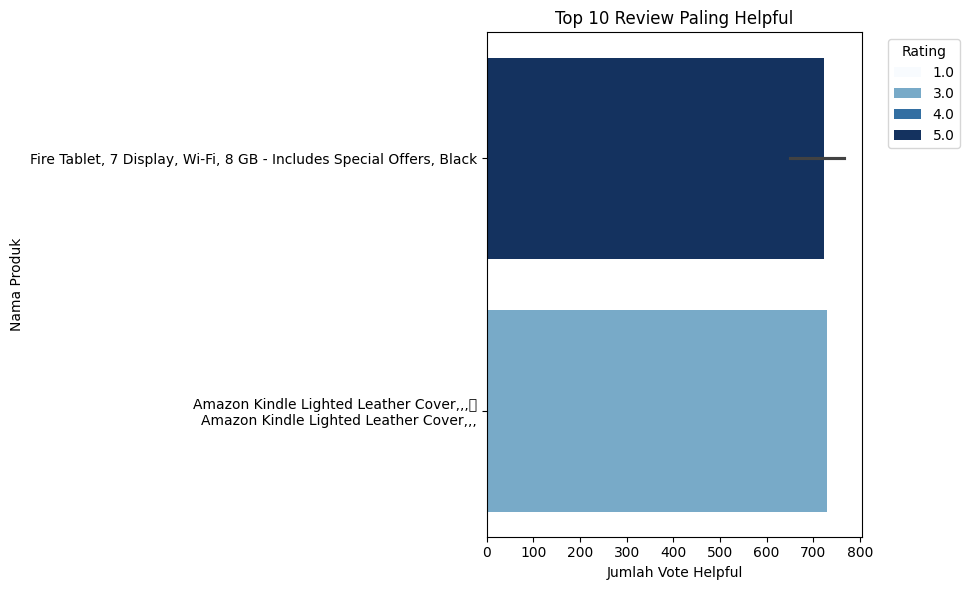

In [86]:
top_helpful = df.nlargest(10, 'reviews.numHelpful')[['name', 'reviews.rating', 'reviews.numHelpful']]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_helpful, x='reviews.numHelpful', y='name', hue='reviews.rating',
            palette='Blues', dodge=False)
plt.title('Top 10 Review Paling Helpful')
plt.xlabel('Jumlah Vote Helpful')
plt.ylabel('Nama Produk')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Review yang banyak mendapat vote "helpful" dari pengguna lain biasanya ditulis dengan detail dan jujur — bisa positif maupun negatif. Insight ini membantu memahami jenis konten review yang paling dipercaya oleh calon pembeli.
Hanya 2 produk yang mendominasi vote helpful tertinggi, yaitu Fire Tablet 7" Black (rating 5) dan Amazon Kindle Lighted Leather Cover (rating 3) dengan masing-masing ~720-814 vote — menunjukkan review detail pada produk populer lebih dipercaya pengguna lain.

### Insight 7 — Distribusi Rating (Imbalance Check)

/tmp/ipykernel_2757/1077331223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


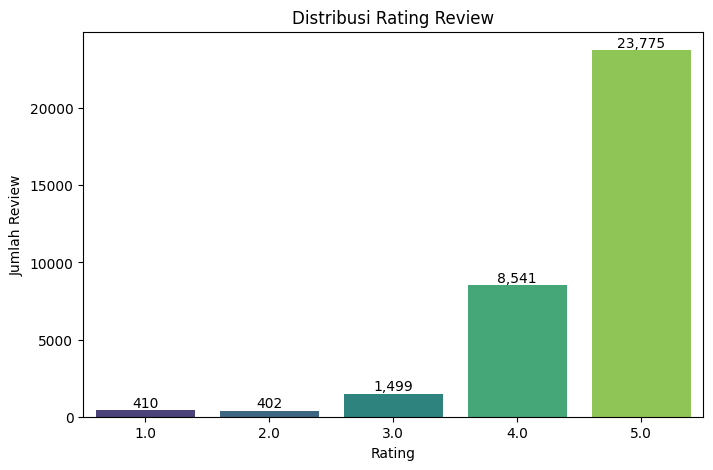

Distribusi Rating:

Rating 1.0: 410 review (1.18%)
Rating 2.0: 402 review (1.16%)
Rating 3.0: 1,499 review (4.33%)
Rating 4.0: 8,541 review (24.67%)
Rating 5.0: 23,775 review (68.66%)

Ringkasan Imbalance:
Mayoritas  : 68.66%
Minoritas  : 1.16%
Rasio imbalance : 59.14x


In [87]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='reviews.rating',
    data=df,
    palette='viridis'
)

plt.title('Distribusi Rating Review')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.show()

rating_counts = df['reviews.rating'].value_counts().sort_index()
rating_percent = df['reviews.rating'].value_counts(normalize=True).sort_index() * 100
print("Distribusi Rating:\n")
for rating in rating_counts.index:
    print(
        f"Rating {rating}: "
        f"{rating_counts[rating]:,} review "
        f"({rating_percent[rating]:.2f}%)"
    )

print("\nRingkasan Imbalance:")
print(f"Mayoritas  : {rating_percent.max():.2f}%")
print(f"Minoritas  : {rating_percent.min():.2f}%")
print(f"Rasio imbalance : {rating_counts.max() / rating_counts.min():.2f}x")

Disini merupakan grafik distribusi rating review, disini bisa dilihat bahwa datanya sangat imbalance dimana rating 5 sangat banyak sekali yaitu 23 ribu data sedangkan rating 4 itu sekitar 8500, dan sisanya sedikit untuk rating 1-3. Ini menunjukkan data imbalance yang severe.

### Insight 8

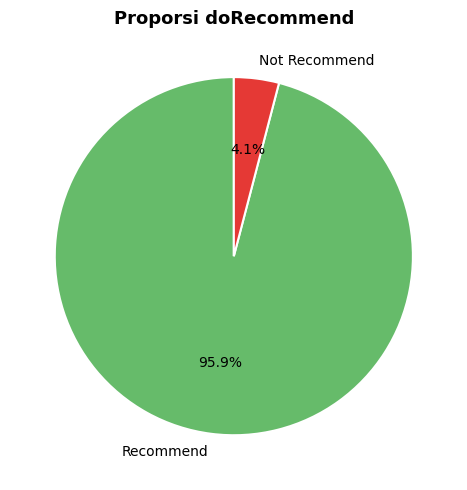

In [88]:
recommend_counts = df['reviews.doRecommend'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(recommend_counts.values,
        labels=['Recommend', 'Not Recommend'],
        autopct='%1.1f%%',
        colors=['#66bb6a', '#e53935'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Proporsi doRecommend', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight 9 — Korelasi Fitur Numerik

In [89]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username', 'year_month',
       'text_length'],
      dtype='object')

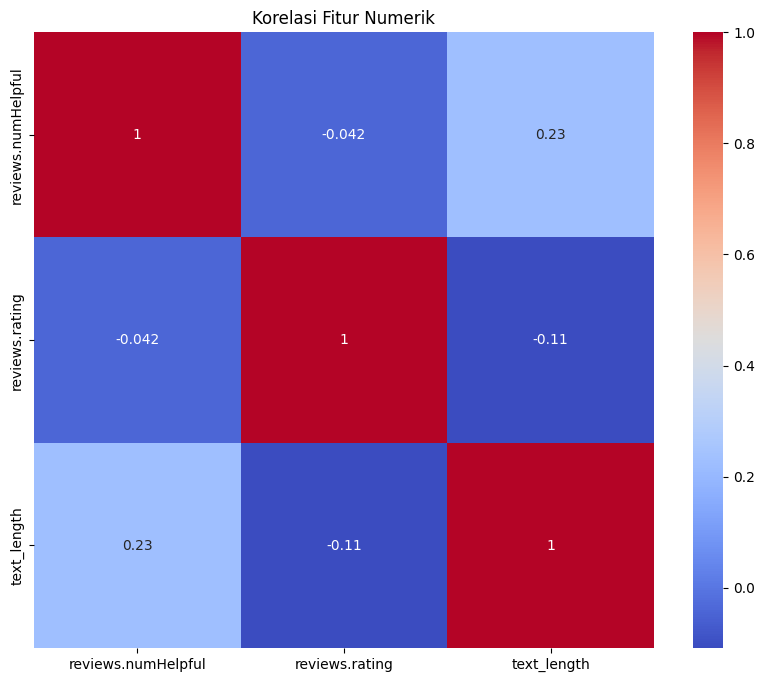

In [90]:
numerical_col = df.select_dtypes('number').drop(columns=['reviews.id','reviews.userCity', 'reviews.userProvince'])
correlation = numerical_col.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()

## Noise or Anomaly Searching

### Anomaly 1 (Missing Value)

In [91]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
reviews.userProvince,100.000000
reviews.userCity,100.000000
reviews.id,99.997115
reviews.didPurchase,99.997115
reviews.dateAdded,30.643393
name,19.503751
reviews.doRecommend,1.713791
reviews.numHelpful,1.526255
year_month,0.351991
reviews.date,0.351991


Penjelasan: Terdapat anomali berupa missing values yang ekstrem pada beberapa fitur. Kolom *reviews.userCity* dan *reviews.userProvince* memiliki 100% data kosong (0 non-null). Selain itu, kolom *reviews.id* dan *reviews.didPurchase* hanya memiliki 1 baris data yang terisi dari total 34.660 baris. Lalu pada kolom *reviews.text* ada 1 kolom null yang kemungkinan di mana pengguna memberikan rating, namun teks ulasannya kosong (NaN). Kolom-kolom ini adalah noise karena tidak memberikan informasi apa-apa dan sebaiknya di-drop pada tahap preprocessing.

### Anomaly 2 (Mixed Data Types)

In [92]:
for col in df.columns:
   if len(df[col].apply(type).unique()) > 1:
      print(f"Tipe data unik di kolom '{col}': {df[col].apply(type).unique()}")


Tipe data unik di kolom 'name': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'asins': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.date': [<class 'pandas._libs.tslibs.timestamps.Timestamp'>
 <class 'pandas._libs.tslibs.nattype.NaTType'>]
Tipe data unik di kolom 'reviews.dateAdded': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.didPurchase': [<class 'float'> <class 'bool'>]
Tipe data unik di kolom 'reviews.doRecommend': [<class 'bool'> <class 'float'>]
Tipe data unik di kolom 'reviews.text': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.title': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.username': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'year_month': [<class 'pandas._libs.tslibs.period.Period'>
 <class 'pandas._libs.tslibs.nattype.NaTType'>]


Penjelasan : Pada pembacaan dataset terdapat 'warning DtypeWarning: Columns (1,10) have mixed types.' Pandas mendeteksi adanya Mixed Data Types (tipe data campuran) pada saat membaca file CSV, tepatnya pada kolom name dan reviews.didPurchase. Ini berarti dalam satu kolom tersebut, ada baris yang bertipe string, ada yang float (karena NaN), atau boolean. Ini adalah anomali struktur data yang bisa menyebabkan error saat model ML dilatih, sehingga tipe datanya harus diseragamkan.

### Anomaly 3 (Mengecek Duplikasi Data)

In [93]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

Jumlah baris duplikat: 0


Penjelasan : Tidak ada data duplikasi data, jadi tidak perlu melakukan preprosesing pada data duplikat.

### Anomaly 4 (Outlier Detection)

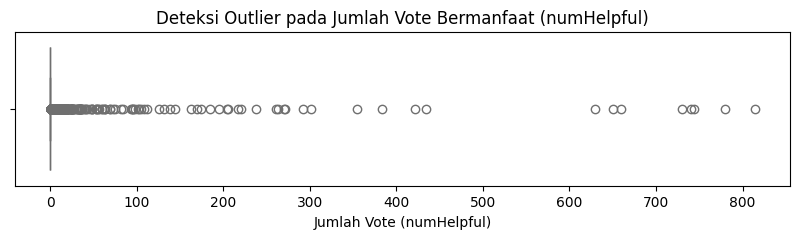

Jumlah ulasan dengan vote 'helpful' lebih dari 50: 58 baris dari total 34660 baris


In [94]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['reviews.numHelpful'], color='skyblue')
plt.title('Deteksi Outlier pada Jumlah Vote Bermanfaat (numHelpful)')
plt.xlabel('Jumlah Vote (numHelpful)')
plt.show()

outliers_helpful = df[df['reviews.numHelpful'] > 50]
print(f"Jumlah ulasan dengan vote 'helpful' lebih dari 50: {len(outliers_helpful)} baris dari total {len(df)} baris")

Penjelasan : Melalui uji statistik deskriptif (df.describe()) dan visualisasi boxplot, ditemukan adanya outlier yang signifikan pada kolom reviews.numHelpful. Mayoritas ulasan (lebih dari 75%) memiliki nilai 0, namun terdapat beberapa ulasan ekstrem yang mendapat ratusan vote (nilai maksimal 814). Meskipun secara statistik ini adalah outlier, mungkin data ini merupakan kejadian organik yang valid (ulasan viral/informatif), sehingga diputuskan untuk tidak dihapus karena fitur teks ulasannya tetap dapat digunakan untuk melatih model NLP.

### Anomaly 5 (Case Inconsistency)

In [95]:
import re

sample_texts = df['reviews.text'].dropna().astype(str).tolist()

variasi_amazon = set()
for text in sample_texts:
    matches = re.findall(r'\b[aA][mM][aA][zZ][oO][nN]\b', text)
    variasi_amazon.update(matches)

print("Bukti Anomali Kapitalisasi pada kata 'Amazon':")
print(variasi_amazon)

Bukti Anomali Kapitalisasi pada kata 'Amazon':
{'amazon', 'AMAZON', 'Amazon', 'AmaZon'}


Penjelasan : Melalui eksplorasi teks, ditemukan anomali berupa inkonsistensi kapitalisasi. Sebagai contoh, sebuah entitas yang sama ('Amazon') ditulis dalam berbagai format oleh pengguna yang berbeda. Hal ini merupakan noise karena dalam pemrosesan NLP mentah, komputer akan menganggap kata-kata tersebut sebagai token yang berbeda-beda.

### Anomaly 6 (Punctuation Noise)

In [96]:
mengandung_simbol = df['reviews.text'].str.contains(r'[^\w\s]', regex=True, na=False)

jumlah_bermasalah = mengandung_simbol.sum()
persentase = (jumlah_bermasalah / len(df)) * 100

print(f"Jumlah ulasan yang mengandung tanda baca/simbol: {jumlah_bermasalah} baris ({persentase:.2f}%)")

print("\nContoh ulasan dengan banyak tanda baca:")
contoh_simbol = df[mengandung_simbol]['reviews.text'].head(3).values
for teks in contoh_simbol:
    print(f"- {teks}")

Jumlah ulasan yang mengandung tanda baca/simbol: 32263 baris (93.08%)

Contoh ulasan dengan banyak tanda baca:
- This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
- great for beginner or experienced person. Bought as a gift and she loves it
- Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...


Penjelasan : Anomali format penulisan terdeteksi pada sebagian besar teks ulasan. Mayoritas pengguna menggunakan tanda baca (koma, titik, tanda hubung) yang sangat bervariasi. Dalam konteks klasifikasi teks dasar, tanda baca ini terhitung sebagai noise yang harus di preprocessing untuk dibersihkan.

### Anomaly 7 (Typo or Slang Vocabulary Noise)

In [97]:
# (pip install pyspellchecker sudah dipindahkan ke cell Import Library di atas)

In [98]:
from spellchecker import SpellChecker

# 1. Menggabungkan semua teks ulasan menjadi satu string raksasa
# Asumsinya teks sudah dalam bentuk lowercase dan tidak ada tanda baca (dari preprocessing kita sebelumnya)
semua_teks = " ".join(df['reviews.text'].dropna())

# 2. Memecah teks menjadi kata per kata dan mengambil kata uniknya saja menggunakan set()
kata_unik = set(semua_teks.split())
print(f"Total kata unik (vocabulary) di dataset: {len(kata_unik)}")

# 3. Inisialisasi SpellChecker bahasa Inggris
spell = SpellChecker()

# 4. Mencari kata yang terindikasi typo/slang (tidak ada di kamus)
kata_aneh = spell.unknown(kata_unik)

print(f"Jumlah kata yang terindikasi typo/slang: {len(kata_aneh)}")
print("\nContoh 50 kata aneh pertama:")
print(list(kata_aneh)[:50])

Total kata unik (vocabulary) di dataset: 37773
Jumlah kata yang terindikasi typo/slang: 23053

Contoh 50 kata aneh pertama:
['wow!!', '15%', 'advertisement,', 'curriculums,', 'useful!', 'great!!!!!!', 'now.......', '"hear"', 'ppi)', 'surprisely', 'prevalent,', 'didn���t', 'neices', 'youse', 'kf', 'read...great', 'smarthome.', 'connector.', 'unbelievable!!!', 'where.)"alexa,', '$50.00...it', 'alarm.com', 'navigate-silk', 'satisfying.', 'echo...and', 'for...i', 'lotmore', 'improves,', 'fxnow', 'birds,', 'household.', '(9)', 'on/off', 'charged.', 'history.', 'lock/closure', 'respectively).for', 'top...would', 'down!,', 'types.', 'installing.', 'trade.', 'individual,', '44,', 'read-along', 'sound.great', 'goodness!', 'browny', 'on".', 'receiver.']


# **Preprocessing**

## Anomly and Noise Handling

### 1. Missing values handling

In [99]:
cols_to_drop = missing_percentage[missing_percentage > 50].index
cols_to_drop

Index(['reviews.didPurchase', 'reviews.id', 'reviews.userCity',
       'reviews.userProvince'],
      dtype='object')

In [100]:
df_clean = df.copy()
df_clean = df_clean.drop(cols_to_drop, axis=1)
df_clean.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'year_month', 'text_length'],
      dtype='object')

Di sini kami men-drop kolom yang missing valuenya lebih dari 50%, karena jika diimputasi, maka lebih dari 50% informasi kolom pada dataset akan menjadi informasi palsu semua.

In [101]:
missing_percentage = df_clean.isna().sum() / len(df_clean) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
reviews.dateAdded,30.643393
name,19.503751
reviews.doRecommend,1.713791
reviews.numHelpful,1.526255
year_month,0.351991
reviews.date,0.351991
reviews.rating,0.095211
reviews.username,0.020196
reviews.title,0.017311
asins,0.005770


In [102]:
df_clean['reviews.dateAdded'].sort_values()

,reviews.dateAdded
14726,2016-10-15T11:10:42Z
14725,2016-10-15T11:10:42Z
16016,2017-03-06T14:59:25Z
16015,2017-03-06T14:59:25Z
16014,2017-03-06T14:59:25Z
...,...
34655,NaN
34656,NaN
34657,NaN
34658,NaN


In [103]:
df_clean['asins']

,asins
0,B01AHB9CN2
1,B01AHB9CN2
2,B01AHB9CN2
3,B01AHB9CN2
4,B01AHB9CN2
...,...
34655,B006GWO5WK
34656,B006GWO5WK
34657,B006GWO5WK
34658,B006GWO5WK


In [104]:
df_clean = df_clean.drop(['reviews.dateAdded', 'asins'], axis=1)

Di sini kami drop dateAdded dan asins karena kedua fitur tersebut adalah fitur tidak penting

In [105]:
df_clean['text_length']

,text_length
0,143.0
1,75.0
2,131.0
3,593.0
4,613.0
...,...
34655,1158.0
34656,255.0
34657,314.0
34658,231.0


In [106]:
# Imputasi text_length: isi NaN dengan panjang teks aktual di kolom reviews.text
df_clean['text_length'] = df_clean['text_length'].fillna(
    df_clean['reviews.text'].str.len()
)

text_length berisi panjang karakter teks ulasan. NaN diisi dengan panjang teks dari kolom `reviews.text` menggunakan `.str.len()` (bukan `len(df_clean['reviews.text'])` yang hanya mengembalikan jumlah baris).

In [107]:
df_clean['reviews.doRecommend'].isna().sum()

np.int64(594)

In [108]:
df_clean = df_clean.dropna(subset=['reviews.doRecommend'])

In [109]:
df_clean['reviews.doRecommend'].unique()

array([True, False], dtype=object)

Karena di sini yg hilang cuma 594 dari 30rb an data, jadi daripada memberikan infromasi palsu, mending di drop aja

In [110]:
df_clean['reviews.username'] = df_clean['reviews.username'].fillna('Unknown')
df_clean['reviews.title'] = df_clean['reviews.title'].fillna('Unknown')
df_clean['name'] = df_clean['name'].fillna('Unknown')

In [111]:
df_clean['reviews.numHelpful'].unique()

array([  0.,   1.,   2.,   3.,  55.,   4.,  24.,  11.,  42.,  62.,   7.,
         8.,   6.,  10.,  36.,  16.,  15.,  13.,   5.,   9., 105.,  25.,
        21.,  14.,  20.,  22.,  12.,  96., 102.,  34.,  17.,  73., 109.,
        19.,  27.,  39.,  57.,  18.,  40.,  33.,  28., 103.,  26.,  32.,
        43.,  37.,  64.,  23.,  48.,  49.,  95.,  31.,  63.,  nan,  54.,
        30.,  46.,  69.])

untuk username, name, dan title, karena kalau pakai modus bakal ga akurat, maka di sini kami isi dengan Unknown saja

In [112]:
df_clean['reviews.numHelpful'].isna().sum()

np.int64(2)

In [113]:
df_clean = df_clean.dropna(subset=['reviews.numHelpful'])

In [114]:
missing_percentage = df_clean.isna().sum() / len(df_clean) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0


### 2. Mixed Data types handling

In [115]:
for col in df_clean.columns:

    if len(df_clean[col].apply(type).unique()) > 1:
       print(f"Tipe data unik di kolom '{col}': {df_clean[col].apply(type).unique()}")


Karena kita telah menghilangkan missing value, maka sekarang sudah tidak ada kolom dengan tipe data yg tercapur

### 3. Case Inconsistency handling

In [116]:
categorical_col = df_clean.select_dtypes('object').columns
categorical_col

Index(['id', 'name', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username'],
      dtype='object')

In [117]:
for col in categorical_col:
    df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()

In [118]:
sample_texts = df_clean['reviews.text'].dropna().astype(str).tolist()

variasi_amazon = set()
for text in sample_texts:
    matches = re.findall(r'\b[aA][mM][aA][zZ][oO][nN]\b', text)
    variasi_amazon.update(matches)

print("Bukti Anomali Kapitalisasi pada kata 'Amazon':")
print(variasi_amazon)

Bukti Anomali Kapitalisasi pada kata 'Amazon':
{'amazon'}


Untuk case yang tidak konsistem di sini kami lower kan dan hilangkan spasi kanan kirinya biar konsisten

### 4. Punctuation noise handling

In [119]:
df_clean['reviews.text']

,reviews.text
0,this product so far has not disappointed. my children love to use it and i like the ability to monitor control what content they see with ease.
1,great for beginner or experienced person. bought as a gift and she loves it
2,"inexpensive tablet for him to use and learn on, step up from the nabi. he was thrilled with it, learn how to skype on it already..."
3,i've had my fire hd 8 two weeks now and i love it. this tablet is a great value.we are prime members and that is where this tablet shines. i love being able to easily access all of the prime content as well as movies you can download and watch laterthis has a 1280/800 screen which has some really nice look to it its nice and crisp and very bright infact it is brighter then the ipad pro costing $900 base model. the build on this fire is insanely awesome running at only 7.7mm thick and the smooth glossy feel on the back it is really amazing to hold its like the futuristic tab in ur hands.
4,"i bought this for my grand daughter when she comes over to visit. i set it up with her as the user, entered her age and name and now amazon makes sure that she only accesses sites and content that are appropriate to her age. simple to do and she loves the capabilities. i also bought and installed a 64gig sd card which gives this little tablet plenty of storage. for the price i think this tablet is best one out there. you can spend hundreds of dollars more for additional speed and capacity but when it comes to the basics this tablets does everything that most people will ever need at a fraction of the cost."
...,...
34620,"i am now able to stream tv and movies from around the world, works great."
34621,"best streaming device , very portable , amazing picture"
34622,"simply the best to watch tv series and movies. it works even better if you are an amazon prime subscriber, with access to a many free goodies."
34623,"i was looking for ways to cut cost from a raising cable bill and a friend suggested i try the amazon fire. at first i didn���t know if this was something i could do. once i was able to maneuver through the process, i love it."


In [120]:
# 1. Mengganti semua karakter selain huruf, angka (\w), dan whitespace (\s) dengan spasi (' ')
df_clean['reviews.text'] = df_clean['reviews.text'].str.replace(r'[^\w\s]', ' ', regex=True)

# 2. Membersihkan spasi ganda/berlebih yang mungkin terbentuk dari langkah pertama
df_clean['reviews.text'] = df_clean['reviews.text'].str.replace(r'\s+', ' ', regex=True)

# 3. (Opsional) Memastikan tidak ada spasi nyangkut di awal atau akhir kalimat lagi
df_clean['reviews.text'] = df_clean['reviews.text'].str.strip()

In [121]:
mengandung_simbol = df_clean['reviews.text'].str.contains(r'[^\w\s]', regex=True, na=False)

jumlah_bermasalah = mengandung_simbol.sum()
persentase = (jumlah_bermasalah / len(df_clean)) * 100

print(f"Jumlah ulasan yang mengandung tanda baca/simbol: {jumlah_bermasalah} baris ({persentase:.2f}%)")

print("\nContoh ulasan dengan banyak tanda baca:")
contoh_simbol = df_clean[mengandung_simbol]['reviews.text'].head(3).values
for teks in contoh_simbol:
    print(f"- {teks}")

Jumlah ulasan yang mengandung tanda baca/simbol: 0 baris (0.00%)

Contoh ulasan dengan banyak tanda baca:


di sini kami mengganti tanda baca dan symbol dengan spasi kosong agar tidak merusak hassil dari TFIDF nanti, lalu setelah itu kami juga menghapus spasi ganda jika dari pemrosesan sebelumnya menghasilkan spasi ganda.

In [122]:
df_clean['reviews.text'].iloc[0]

'this product so far has not disappointed my children love to use it and i like the ability to monitor control what content they see with ease'

### 5. Typo or Slang Vocabulary Noise handling

In [123]:
# 1. Menggabungkan semua teks ulasan menjadi satu string raksasa
# Asumsinya teks sudah dalam bentuk lowercase dan tidak ada tanda baca (dari preprocessing kita sebelumnya)
semua_teks = " ".join(df_clean['reviews.text'].dropna())

# 2. Memecah teks menjadi kata per kata dan mengambil kata uniknya saja menggunakan set()
kata_unik = set(semua_teks.split())
print(f"Total kata unik (vocabulary) di dataset: {len(kata_unik)}")

# 3. Inisialisasi SpellChecker bahasa Inggris
spell = SpellChecker()

# 4. Mencari kata yang terindikasi typo/slang (tidak ada di kamus)
kata_aneh = spell.unknown(kata_unik)

print(f"Jumlah kata yang terindikasi typo/slang: {len(kata_aneh)}")
print("\nContoh 50 kata aneh pertama:")
print(list(kata_aneh)[:50])

Total kata unik (vocabulary) di dataset: 13564
Jumlah kata yang terindikasi typo/slang: 3446

Contoh 50 kata aneh pertama:
['0ne', 'hbo', 'wemu', 'nowrealize', 'g4', 'tjis', 'usecheapexpandable', 'aweseome', 'grest', 'kinde', 'nterface', 'api', 'html', 'wwan', 'tempature', 'marekting', 'versility', 'addtion', 'enjoiy', 'mucheveryday', 'funis', 'bitstream', 'ghz', 'daughterthere', 'voila', 'fastcons', 'luvit', 'thhought', 'shoppin', 'hogjly', 'chnls', 'youtubing', 'gbox', 'showroomevery', 'pagesif', 'compatable', 'paretal', 'slingbox', 'surprisely', 'wtf', 'inthe', 'therfore', 'samaumg', 'neices', 'youse', 'expecxted', 'tihs', 'nough', 'kf', 'serius']


Kata-kata yang terindikasi typo/slang dibiarkan karena penanganannya dilakukan secara implisit melalui parameter `min_df=3` pada TF-IDF di tahap selanjutnya, sehingga kata yang sangat jarang muncul (termasuk typo acak) akan diabaikan secara otomatis.

## Feature Engineering

In [124]:
# Lanjutkan dari df_clean hasil preprocessing sebelumnya
# (TIDAK perlu reset ke df mentah)
df_clean['reviews.rating'] = pd.to_numeric(df_clean['reviews.rating'], errors='coerce')
df_clean = df_clean.dropna(subset=['reviews.rating']).reset_index(drop=True)

print(f'Shape setelah validasi rating: {df_clean.shape}')

Shape setelah validasi rating: (34064, 17)


Memastikan kolom `reviews.rating` bertipe numerik dan tidak ada nilai NaN. Tidak perlu reset ke `df` mentah karena `df_clean` sudah melalui seluruh tahap cleaning sebelumnya.

In [125]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df_clean['sentiment'] = df_clean['reviews.rating'].apply(rating_to_sentiment)
print("Distribusi Label Sentimen:")
print(df_clean['sentiment'].value_counts())

Distribusi Label Sentimen:
sentiment
Positif    31856
Netral      1470
Negatif      738
Name: count, dtype: int64


/tmp/ipykernel_2757/883999072.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentiment', data=df_clean, palette='Set2')


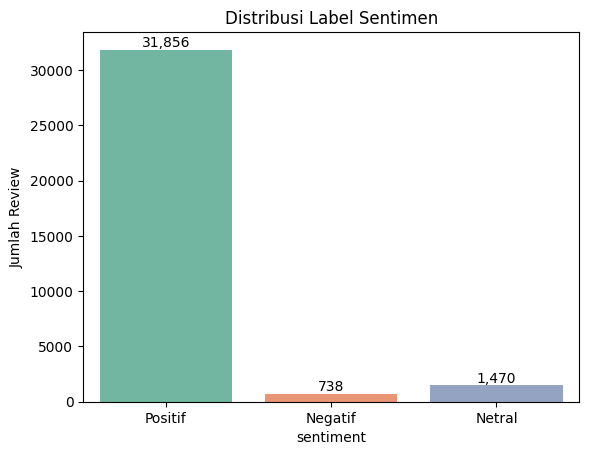

In [126]:
ax = sns.countplot(x='sentiment', data=df_clean, palette='Set2')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Label Sentimen')
plt.ylabel('Jumlah Review')
plt.show()

Setelah melakukan binning dan membuat Label sentimen, bisa dilihat bahwa hasilnya sangat imbalance sekali yaitu lebih dari 32 ribu merupakan positif, sedangkan netral dan negatif dibawah 1.5 ribu

In [127]:
df_clean['text_length'] = df_clean['reviews.text'].str.len()
df_clean['word_count']  = df_clean['reviews.text'].str.split().str.len()

print("\nStatistik Fitur Numerik Baru:")
print(df_clean[['text_length', 'word_count']].describe().round(2))


Statistik Fitur Numerik Baru:
       text_length  word_count
count     34064.00    34064.00
mean        153.09       30.56
std         163.78       32.43
min           0.00        0.00
25%          68.00       14.00
50%         104.00       21.00
75%         178.00       36.00
max        8167.00     1611.00


Menambahkan fitur baru saja yaitu text_length dan word_count

In [128]:
le = LabelEncoder()
df_clean['label'] = le.fit_transform(df_clean['sentiment'])

print("Pemetaan Label:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {enc}")

Pemetaan Label:
  Negatif → 0
  Netral → 1
  Positif → 2


In [129]:
df_clean['reviews.title'] = df_clean['reviews.title'].fillna('')
df_clean['reviews.text'] = df_clean['reviews.text'].fillna('')
df_clean['reviews.numHelpful'] = df_clean['reviews.numHelpful'].fillna(0)


df_clean['combined_text'] = df_clean['reviews.title'] + " " + df_clean['reviews.text']


X_raw = df_clean[['combined_text', 'reviews.numHelpful']]
y = df_clean['label']


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=33,
    stratify=y
)


tfidf = TfidfVectorizer(max_features=5000)

X_train_text = tfidf.fit_transform(X_train_raw['combined_text'])
X_test_text = tfidf.transform(X_test_raw['combined_text'])


scaler = MinMaxScaler()

X_train_num = scaler.fit_transform(X_train_raw[['reviews.numHelpful']])
X_test_num = scaler.transform(X_test_raw[['reviews.numHelpful']])


X_train_final = sp.hstack([X_train_text, X_train_num])
X_test_final = sp.hstack([X_test_text, X_test_num])


print(f"Ukuran data training : {X_train_final.shape}")
print(f"Ukuran data testing  : {X_test_final.shape}")

Ukuran data training : (27251, 5001)
Ukuran data testing  : (6813, 5001)


In [130]:
X_raw

,combined_text,reviews.numHelpful
0,kindle this product so far has not disappointed my children love to use it and i like the ability to monitor control what content they see with ease,0.0
1,very fast great for beginner or experienced person bought as a gift and she loves it,0.0
2,beginner tablet for our 9 year old son. inexpensive tablet for him to use and learn on step up from the nabi he was thrilled with it learn how to skype on it already,0.0
3,good!!! i ve had my fire hd 8 two weeks now and i love it this tablet is a great value we are prime members and that is where this tablet shines i love being able to easily access all of the prime content as well as movies you can download and watch laterthis has a 1280 800 screen which has some really nice look to it its nice and crisp and very bright infact it is brighter then the ipad pro costing 900 base model the build on this fire is insanely awesome running at only 7 7mm thick and the smooth glossy feel on the back it is really amazing to hold its like the futuristic tab in ur hands,0.0
4,fantastic tablet for kids i bought this for my grand daughter when she comes over to visit i set it up with her as the user entered her age and name and now amazon makes sure that she only accesses sites and content that are appropriate to her age simple to do and she loves the capabilities i also bought and installed a 64gig sd card which gives this little tablet plenty of storage for the price i think this tablet is best one out there you can spend hundreds of dollars more for additional speed and capacity but when it comes to the basics this tablets does everything that most people will ever need at a fraction of the cost,0.0
...,...,...
34059,works great i am now able to stream tv and movies from around the world works great,0.0
34060,the best best streaming device very portable amazing picture,1.0
34061,love it simply the best to watch tv series and movies it works even better if you are an amazon prime subscriber with access to a many free goodies,0.0
34062,"try it, you will like it i was looking for ways to cut cost from a raising cable bill and a friend suggested i try the amazon fire at first i didn t know if this was something i could do once i was able to maneuver through the process i love it",0.0


In [131]:
df_clean.columns

Index(['id', 'name', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateSeen', 'reviews.doRecommend',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'year_month',
       'text_length', 'sentiment', 'word_count', 'label', 'combined_text'],
      dtype='object')

Penjelasan: Melakukan train_test_split sebelum ekstraksi fitur menggunakan TF-IDF untuk mencegah data leakage. Jika dilakukan TF-IDF dulu, nanti data train bisa melihat data test.

In [132]:
pd.set_option('display.max_colwidth', None)
print(df['reviews.text'].head(10))

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
1                                                                                                                                                                                                                                                                                                                                                                                            

## Advanced Text Preprocessing

In [133]:
resources = [
    'punkt',
    'stopwords',
    'wordnet',
    'omw-1.4',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'vader_lexicon'
]

for r in resources:
    nltk.download(r)
!pip install contractions

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [134]:
import contractions
stop_words_exp = set(stopwords.words('english'))

# Ambil otomatis negasi dari NLTK dan simpan
negation_words = {word for word in stop_words_exp if "n't" in word or word in ['not', 'no', 'nor']}

# Custom Stopwords: Hapus negasi, tambahkan to-be
custom_stopwords_exp = stop_words_exp - negation_words
custom_stopwords_exp.update(['am', 'is', 'are', 'was', 'were', 'be', 'been', 'being'])

lemmatizer_exp = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text) # Menggunakan library, lebih komprehensif
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [t for t in tokens if t not in custom_stopwords_exp and len(t) > 1]
    tokens = [lemmatizer_exp.lemmatize(t) for t in tokens]

    return " ".join(tokens)

In [135]:
df_clean['combined_raw'] = df_clean['reviews.title'].fillna('') + ' ' + df_clean['reviews.text'].fillna('')

# Preprocessing teks
df_clean['combinedtext_exp'] = df_clean['combined_raw'].apply(clean_text)

# Ekstraksi fitur numerik dari teks dasar
df_clean['textlength_exp'] = df_clean['combinedtext_exp'].str.len()
df_clean['wordcount_exp'] = df_clean['combinedtext_exp'].str.split().str.len()

Fungsi2 Feature Extraction

In [136]:
# --- 1. FITUR INDEPENDEN

vader_analyzer = SentimentIntensityAnalyzer()

def get_vader_compound(text):
    """Mengambil skor gabungan VADER dari teks mentah."""
    return vader_analyzer.polarity_scores(str(text))['compound']

def get_readability_score(text):
    """Mengambil skor Flesch Reading Ease dari teks mentah."""
    text_str = str(text)
    if len(text_str.split()) < 3:
        return 0
    return textstat.flesch_reading_ease(text_str)

def get_pos_noun_verb_ratio(text):
    """Menghitung rasio Noun dan Verb sebagai representasi POS tagging"""
    tokens = nltk.word_tokenize(str(text))
    pos_tags = nltk.pos_tag(tokens)

    counts = nltk.FreqDist(tag[:2] for word, tag in pos_tags)
    total = max(len(tokens), 1)

    return counts.get('NN', 0) / total, counts.get('VB', 0) / total

# --- 2. FITUR DEPENDEN
def apply_lda_features(X_train_text, X_test_text, n_topics=5):
    """
    Melakukan ekstraksi probabilitas topik LDA.
    Harus menggunakan raw token counts (CountVectorizer), bukan TF-IDF.
    """
    # Fit pada training data
    tf_vectorizer = CountVectorizer(max_features=1000, stop_words='english')
    X_train_tf = tf_vectorizer.fit_transform(X_train_text)
    X_test_tf = tf_vectorizer.transform(X_test_text)

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)

    # Fit LDA hanya pada data training, transform ke train dan test
    train_lda_features = lda.fit_transform(X_train_tf)
    test_lda_features = lda.transform(X_test_tf)

    return train_lda_features, test_lda_features

## Data Splitting

In [137]:
df_clean.head(1)

,id,name,brand,categories,keys,manufacturer,reviews.date,reviews.dateSeen,reviews.doRecommend,reviews.numHelpful,...,year_month,text_length,sentiment,word_count,label,combined_text,combined_raw,combinedtext_exp,textlength_exp,wordcount_exp
0,avqkihwdv8e3d1o-lebb,"all-new fire hd 8 tablet, 8 hd display, wi-fi, 16 gb - includes special offers, magenta",amazon,"electronics,ipad & tablets,all tablets,fire tablets,tablets,computers & tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/b01ahb9cn2",amazon,2017-01-13 00:00:00+00:00,"2017-06-07t09:04:00.000z,2017-04-30t00:45:00.000z",true,0.0,...,2017-01,141,Positif,27,2,kindle this product so far has not disappointed my children love to use it and i like the ability to monitor control what content they see with ease,kindle this product so far has not disappointed my children love to use it and i like the ability to monitor control what content they see with ease,kindle product far not disappointed child love use like ability monitor control content see ease,96,15


## Metode2 Feature Extraction

In [138]:
df_clean['vader_score'] = df_clean['combined_raw'].apply(get_vader_compound)
df_clean['readability'] = df_clean['combined_raw'].apply(get_readability_score)

# Apply POS tagging dan pecah menjadi 2 kolom
df_clean[['noun_ratio', 'verb_ratio']] = pd.DataFrame(
    df_clean['combined_raw'].apply(get_pos_noun_verb_ratio).tolist(),
    index=df_clean.index
)

In [139]:
Xraw_exp = df_clean[['combinedtext_exp', 'combined_raw', 'reviews.numHelpful', 'textlength_exp', 'wordcount_exp', 'vader_score', 'readability', 'noun_ratio', 'verb_ratio']]
y_exp = df_clean['label']

X_trainraw_exp, X_testraw_exp, y_train_exp, y_test_exp = train_test_split(
    Xraw_exp, y_exp, test_size=0.2, random_state=33, stratify=y_exp
)

print("New splits created including feature columns.")
print("Distribusi y_train:", Counter(y_train_exp))

New splits created including feature columns.
Distribusi y_train: Counter({2: 25485, 1: 1176, 0: 590})


In [140]:
tfidf_exp = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

# TF-IDF
X_traintext_exp = tfidf_exp.fit_transform(X_trainraw_exp['combinedtext_exp'])
X_testtext_exp = tfidf_exp.transform(X_testraw_exp['combinedtext_exp'])

# LDA Features
train_lda, test_lda = apply_lda_features(X_trainraw_exp['combinedtext_exp'], X_testraw_exp['combinedtext_exp'])

# Scaling numerical features (Fixing the KeyError by ensuring these exist in the split)
num_cols_exp = ['reviews.numHelpful', 'textlength_exp', 'wordcount_exp',
                'vader_score', 'readability', 'noun_ratio', 'verb_ratio']

scaler_exp = MinMaxScaler()
X_trainnum_exp = scaler_exp.fit_transform(X_trainraw_exp[num_cols_exp])
X_testnum_exp = scaler_exp.transform(X_testraw_exp[num_cols_exp])

# Final Horizontal Stack
X_trainfinal_exp = sp.hstack(
    [X_traintext_exp, sp.csr_matrix(X_trainnum_exp), sp.csr_matrix(train_lda)],
    format='csr'
)

X_testfinal_exp = sp.hstack(
    [X_testtext_exp, sp.csr_matrix(X_testnum_exp), sp.csr_matrix(test_lda)],
    format='csr'
)

print("Ukuran data training eksperimen:", X_trainfinal_exp.shape)
print("Ukuran data testing eksperimen :", X_testfinal_exp.shape)

Ukuran data training eksperimen: (27251, 5012)
Ukuran data testing eksperimen : (6813, 5012)


In [141]:
Xraw_exp.head(1)

,combinedtext_exp,combined_raw,reviews.numHelpful,textlength_exp,wordcount_exp,vader_score,readability,noun_ratio,verb_ratio
0,kindle product far not disappointed child love use like ability monitor control content see ease,kindle this product so far has not disappointed my children love to use it and i like the ability to monitor control what content they see with ease,0.0,96,15,0.9194,54.536429,0.178571,0.321429


### Test Baseline

In [143]:
baseline_models = {
    'LinearSVC (Base)': LinearSVC(max_iter=4000, random_state=42),
    'Random Forest (Base)': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM (RBF Kernel)': LogisticRegression(max_iter=1000, random_state=42)
}

print("=== BASELINE EXPERIMENT RESULTS ===")
target_names = ['Negatif', 'Netral', 'Positif']
for name, model in baseline_models.items():
    model.fit(X_trainfinal_exp, y_train_exp)
    y_pred = model.predict(X_testfinal_exp)

    acc = accuracy_score(y_test_exp, y_pred)
    f1_mac = f1_score(y_test_exp, y_pred, average='macro')

    print(f"{name:<20} | Accuracy: {acc:.4f} | Macro F1: {f1_mac:.4f}")
    print("Classification Report")
    print(classification_report(y_test_exp, y_pred, target_names=target_names))
    print("="*50)


=== BASELINE EXPERIMENT RESULTS ===
LinearSVC (Base)     | Accuracy: 0.9400 | Macro F1: 0.5674
Classification Report
              precision    recall  f1-score   support

     Negatif       0.56      0.43      0.48       148
      Netral       0.38      0.18      0.25       294
     Positif       0.96      0.99      0.97      6371

    accuracy                           0.94      6813
   macro avg       0.63      0.53      0.57      6813
weighted avg       0.92      0.94      0.93      6813

Random Forest (Base) | Accuracy: 0.9369 | Macro F1: 0.3843
Classification Report
              precision    recall  f1-score   support

     Negatif       0.56      0.07      0.12       148
      Netral       0.62      0.03      0.06       294
     Positif       0.94      1.00      0.97      6371

    accuracy                           0.94      6813
   macro avg       0.71      0.37      0.38      6813
weighted avg       0.92      0.94      0.91      6813

SVM (RBF Kernel)     | Accuracy: 0.9428 

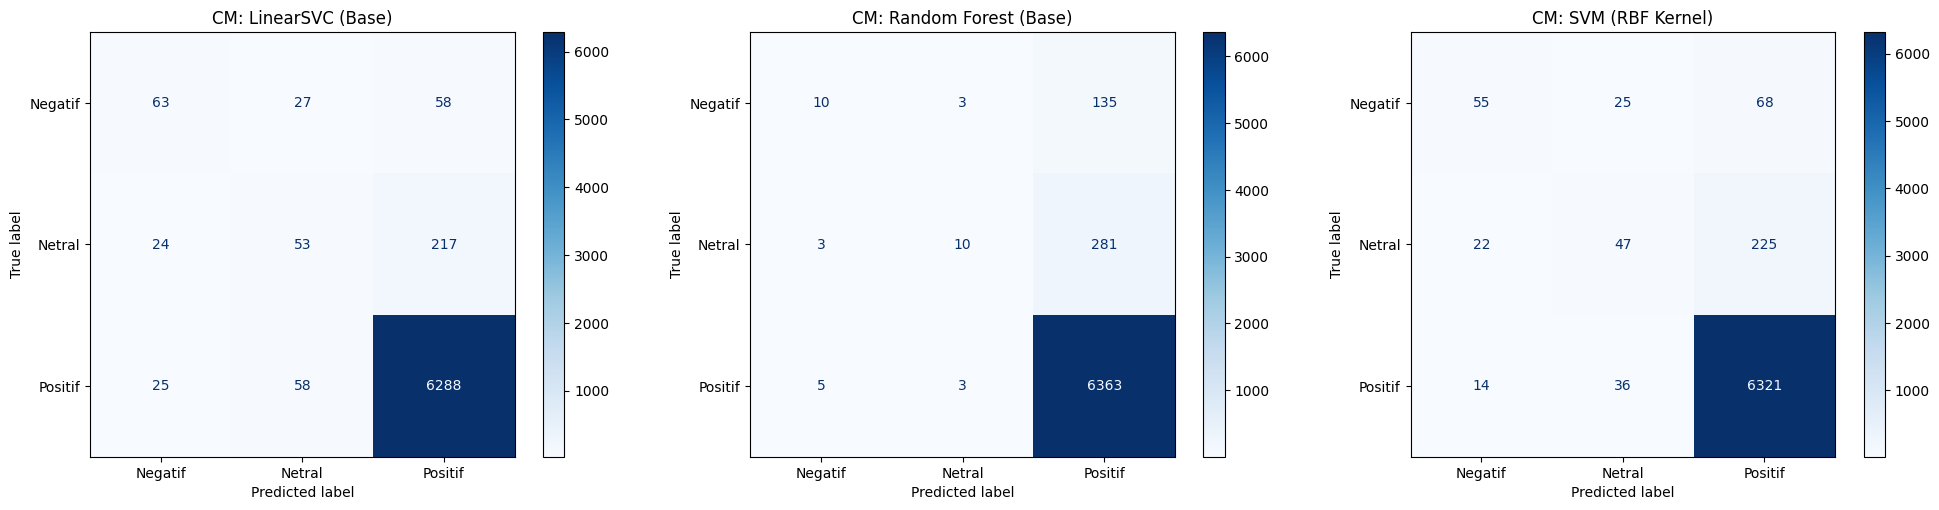

In [144]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
display_labels = ['Negatif', 'Netral', 'Positif']

for i, (name, model) in enumerate(baseline_models.items()):
    y_pred_baseline = model.predict(X_testfinal_exp)
    cm = confusion_matrix(y_test_exp, y_pred_baseline)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'CM: {name}')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

In [145]:
y_train_exp.value_counts()

,count
label,
2,25485
1,1176
0,590


In [146]:

rus_exp = RandomUnderSampler(
    sampling_strategy={0: 590, 1: 1176, 2: 1200},
    random_state=42
)

X_train_rus_exp, y_train_rus_exp = rus_exp.fit_resample(
    X_trainfinal_exp,
    y_train_exp
)

print('Distribusi setelah RandomUnderSampler:', Counter(y_train_rus_exp))

Distribusi setelah RandomUnderSampler: Counter({2: 1200, 1: 1176, 0: 590})


In [147]:
X_train_tl_exp = X_train_rus_exp
y_train_tl_exp = y_train_rus_exp

print('Distribusi data training (siap pakai):', Counter(y_train_tl_exp))

# Train SVM dengan data yang sudah di-resample
svm_tl_exp = LinearSVC(max_iter=4000, random_state=42, class_weight='balanced')
svm_tl_exp.fit(X_train_tl_exp, y_train_tl_exp)

y_pred_tl_exp = svm_tl_exp.predict(X_testfinal_exp)

macro_f1_tl_exp = f1_score(y_test_exp, y_pred_tl_exp, average='macro')
acc_tl_exp     = accuracy_score(y_test_exp, y_pred_tl_exp)

print('\n=== SVM + RandomUnderSampler + class_weight ===')
print(f'Accuracy : {acc_tl_exp:.4f}')
print(f'Macro F1 : {macro_f1_tl_exp:.4f}')
print('\nClassification Report:')
print(classification_report(y_test_exp, y_pred_tl_exp, target_names=['Negatif','Netral','Positif']))

Distribusi data training (siap pakai): Counter({2: 1200, 1: 1176, 0: 590})

=== SVM + RandomUnderSampler + class_weight ===
Accuracy : 0.7911
Macro F1 : 0.4942

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.26      0.61      0.37       148
      Netral       0.14      0.61      0.23       294
     Positif       0.99      0.80      0.89      6371

    accuracy                           0.79      6813
   macro avg       0.46      0.68      0.49      6813
weighted avg       0.93      0.79      0.85      6813



## Weighted Model

In [148]:
from sklearn.ensemble import VotingClassifier

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_exp)
y_test_encoded = label_encoder.transform(y_test_exp)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbosity=-1
)

# Weighted Ensemble
model_weights = [0.6, 0.4]

ensemble_weighted = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgb_model)
    ],
    voting='soft',
    weights=model_weights,
    n_jobs=-1
)

# Ensemble
print("Sedang melatih Weighted Ensemble Model (XGBoost + LightGBM)...")
ensemble_weighted.fit(X_trainfinal_exp, y_train_encoded)
print("Pelatihan selesai!\n")

# Evaluasi
y_pred_encoded = ensemble_weighted.predict(X_testfinal_exp)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

acc = accuracy_score(y_test_exp, y_pred)
f1_mac = f1_score(y_test_exp, y_pred, average='macro')

target_names = [str(cls) for cls in label_encoder.classes_]
print()
print("=== WEIGHTED ENSEMBLE RESULTS ===")
print(f"Bobot Model -> XGBoost: {model_weights[0]} | LightGBM: {model_weights[1]}")
print(f"Accuracy    : {acc:.4f}")
print(f"Macro F1    : {f1_mac:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_exp, y_pred, target_names=target_names))

Sedang melatih Weighted Ensemble Model (XGBoost + LightGBM)...
Pelatihan selesai!



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== WEIGHTED ENSEMBLE RESULTS ===
Bobot Model -> XGBoost: 0.6 | LightGBM: 0.4
Accuracy    : 0.9392
Macro F1    : 0.5795

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.45      0.47       148
           1       0.41      0.23      0.29       294
           2       0.96      0.98      0.97      6371

    accuracy                           0.94      6813
   macro avg       0.63      0.55      0.58      6813
weighted avg       0.93      0.94      0.93      6813



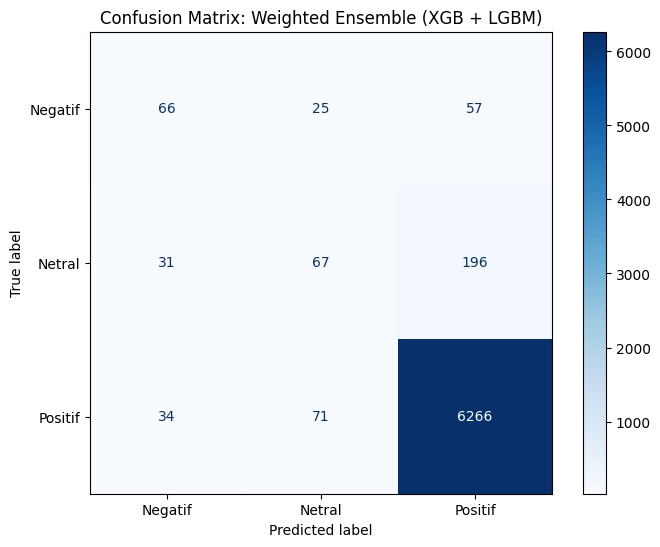

In [149]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix for the Weighted Ensemble
cm_ensemble = confusion_matrix(y_test_exp, y_pred)

# Map original labels for display
display_labels = ['Negatif', 'Netral', 'Positif']

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ensemble, display_labels=display_labels)

# Plot the matrix
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix: Weighted Ensemble (XGB + LGBM)')
plt.grid(False)
plt.show()

### K-Fold Cross Validation

In [150]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Memulai Cross-Validation (5-Folds) untuk Weighted Ensemble...")
cv_results = cross_val_score(ensemble_weighted, X_trainfinal_exp, y_train_encoded, cv=skf, scoring='f1_macro', n_jobs=-1)

print(f"Macro F1 Scores per Fold: {cv_results}")
print(f"Rata-rata Macro F1: {cv_results.mean():.4f} (+/- {cv_results.std() * 2:.4f})")

Memulai Cross-Validation (5-Folds) untuk Weighted Ensemble...
Macro F1 Scores per Fold: [0.61015725 0.5935529  0.61220394 0.59428553 0.62936545]
Rata-rata Macro F1: 0.6079 (+/- 0.0265)


In [151]:
y_pred_exp = ensemble_weighted.predict(X_testfinal_exp)
y_proba_exp = ensemble_weighted.predict_proba(X_testfinal_exp)
confidence_score = np.max(y_proba_exp, axis=1)

df_eval = pd.DataFrame({
    'Teks_Mentah': X_testraw_exp['combined_raw'],
    'Teks_Clean': X_testraw_exp['combinedtext_exp'],
    'Ground_Truth': y_test_exp,
    'Prediksi_Model': y_pred_exp,
    'Confidence_Score': confidence_score
})

df_eval['Status'] = np.where(df_eval['Ground_Truth'] == df_eval['Prediksi_Model'], 'Benar', 'Salah')

df_salah = df_eval[df_eval['Status'] == 'Salah'].sort_values(by='Confidence_Score', ascending=False)

df_salah.to_csv("log_error_analysis_ensemble_advancedfeatureextraction.csv", index=False)

print(df_salah.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                                                                                                                                                                                                                                                                                          Teks_Mentah  \
22106                                                                                                                                                                                                         excellent we love it that s me my wife my son daughter in law 2 grand girls all love it   
6317   great but fragile i love that my son loves to read and all so the kindle is perfect for him it updates and is very easy to use i don t like that it s as fragile as it is my 12 year old has plenty of electronics but the screen has already cracked on this one i m not too happy about that   
22945                                                                                                        

In [152]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def nltk_preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

df_clean['reviews.text.nltk'] = df_clean['reviews.text'].apply(nltk_preprocess)
print(df_clean['reviews.text.nltk'].head(3))

0    product far disappoint children love use like abil monitor control content see eas
1                                        great beginn experienc person bought gift love
2                        inexpens tablet use learn step nabi thrill learn skype alreadi
Name: reviews.text.nltk, dtype: object


In [153]:
X_nltk = df_clean['reviews.text.nltk']
y_nltk = df_clean['label']

X_train_nltk, X_test_nltk, y_train_nltk, y_test_nltk = train_test_split(
    X_nltk, y_nltk,
    test_size=0.2,
    random_state=33,
    stratify=y_nltk
)

print(f"Train size : {len(X_train_nltk)}")
print(f"Test size  : {len(X_test_nltk)}")

Train size : 27251
Test size  : 6813


In [154]:
tfidf_nltk = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_nltk_tfidf = tfidf_nltk.fit_transform(X_train_nltk)
X_test_nltk_tfidf  = tfidf_nltk.transform(X_test_nltk)

print(f"Shape X_train TF-IDF (NLTK) : {X_train_nltk_tfidf.shape}")
print(f"Shape X_test  TF-IDF (NLTK) : {X_test_nltk_tfidf.shape}")

Shape X_train TF-IDF (NLTK) : (27251, 10000)
Shape X_test  TF-IDF (NLTK) : (6813, 10000)


In [157]:
print("\nDistribusi label setelah undersampling:")
unique, counts = np.unique(y_train_rus_exp, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c}")


Distribusi label setelah undersampling:
  Label 0: 590
  Label 1: 1176
  Label 2: 1200


In [161]:
models_exp1 = {
    'Naive Bayes'         : MultinomialNB(alpha=1.0),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM'          : LinearSVC(max_iter=2000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'             : XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM'            : LGBMClassifier(random_state=42, n_jobs=-1)
}

results_exp1 = {}
print("Experiment: Undersampling + NLTK")

for name, model in models_exp1.items():
    model.fit(X_train_rus_exp, y_train_rus_exp)
    y_pred = model.predict(X_testfinal_exp)
    acc     = accuracy_score(y_test_exp, y_pred)
    f1_mac  = f1_score(y_test_exp, y_pred, average='macro')

    results_exp1[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'accuracy': acc,
        'f1_macro': f1_mac
    }
    print(f"{name:<22} Macro F1: {f1_mac:.4f}  |  Accuracy: {acc:.4f}")

Experiment: Undersampling + NLTK
Naive Bayes            Macro F1: 0.4450  |  Accuracy: 0.7845
Logistic Regression    Macro F1: 0.5466  |  Accuracy: 0.8269
Linear SVM             Macro F1: 0.5078  |  Accuracy: 0.7932
Random Forest          Macro F1: 0.5118  |  Accuracy: 0.8013
XGBoost                Macro F1: 0.5129  |  Accuracy: 0.7903
LightGBM               Macro F1: 0.5057  |  Accuracy: 0.7812


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Model terbaik: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.41      0.53      0.46       148
      Netral       0.17      0.69      0.27       294
     Positif       0.99      0.84      0.91      6371

    accuracy                           0.83      6813
   macro avg       0.52      0.69      0.55      6813
weighted avg       0.94      0.83      0.87      6813



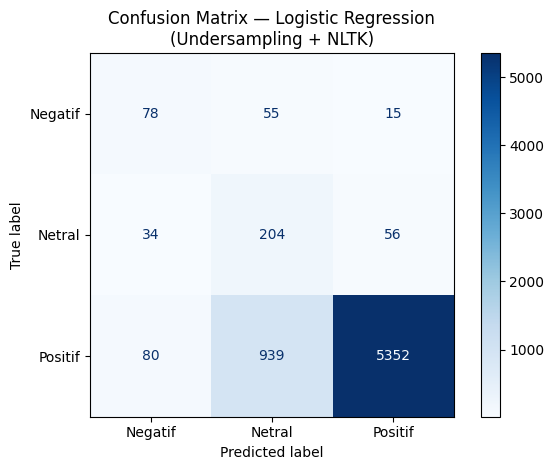

In [162]:
best_model_name = max(results_exp1, key=lambda x: results_exp1[x]['f1_macro'])
best_pred       = results_exp1[best_model_name]['y_pred']

print(f"\nModel terbaik: {best_model_name}")
print("\nClassification Report:")
print(classification_report(y_test_nltk, best_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_nltk, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}\n(Undersampling + NLTK)')
plt.tight_layout()
plt.show()